# SOAL 03 — Baseline KNN, Naive Bayes, dan SVM
**UAS Pembelajaran Mesin — Genap 2025/2026**
**Topik proyek: Optimasi Teknik Machine Learning pada Klasifikasi Tingkat Obesitas (7 kelas)**

Notebook ini membangun **baseline** tiga model wajib (KNN, Naive Bayes, SVM) menggunakan
pipeline preprocessing yang **sama persis** dengan Soal 02 (`src/preprocessing.py`, split
stratified 80:20, `random_state=42`), agar perbandingan antar model adil (apple-to-apple).

Implementasi training memakai fungsi yang sudah ada di proyek UTS (`src/train_knn.py`,
`src/train_naive_bayes.py`, `src/train_svm.py`) — **tidak ditulis ulang dari nol**, melainkan
dipanggil ulang di sini supaya konsisten dengan model yang sudah tersimpan di `models/`, lalu
hasilnya dirangkum khusus untuk kebutuhan Soal 03 (tabel metrik gabungan, confusion matrix
berdampingan, dan diskusi karakteristik model).


In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

BASE_DIR = os.path.abspath("..")
sys.path.insert(0, os.path.join(BASE_DIR, "src"))

from preprocessing import run_preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, classification_report
)

RANDOM_SEED = 42
ORDER_TARGET = [
    "Insufficient_Weight", "Normal_Weight",
    "Overweight_Level_I",  "Overweight_Level_II",
    "Obesity_Type_I",      "Obesity_Type_II", "Obesity_Type_III"
]
MODELS_DIR = os.path.join(BASE_DIR, "models")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
DATA_PATH = os.path.join(BASE_DIR, "data", "ObesityDataSet_raw_and_data_sinthetic.csv")


## 1. Pipeline yang Sama (Reproduksi dari Soal 02)

In [2]:
X, y, scaler, oe = run_preprocessing(
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    clean_data_path=os.path.join(BASE_DIR, "data", "obesity_cleaned_data.csv")
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns, index=X_test.index)
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.joblib"))

print("X_train_sc:", X_train_sc.shape, "| X_test_sc:", X_test_sc.shape)
print("Random seed:", RANDOM_SEED, "| Split: stratified 80:20")


[Load] Dataset dimuat dari: /home/claude/proj/ml-uts-A11.2024.15791-Anza_Ali_S/data/ObesityDataSet_raw_and_data_sinthetic.csv
       Dimensi awal : 2111 baris x 17 kolom
       Missing value: 0
       Duplikat     : 24
[1] Hapus 24 duplikat → 2087 baris tersisa
[2] Binary encoding: Gender, family_history, FAVC, SMOKE, SCC
[3] Ordinal encoding: CAEC & CALC (no=0, Sometimes=1, Frequently=2, Always=3)
    OrdinalEncoder disimpan ke: /home/claude/proj/ml-uts-A11.2024.15791-Anza_Ali_S/models/ordinal_encoder.joblib
[4] One-hot MTRANS → 5 kolom baru: ['MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']
[5] Winsorizing outlier pada: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
[6] Encoding target: Insufficient_Weight=0 … Obesity_Type_III=6

✓ Data bersih disimpan ke: /home/claude/proj/ml-uts-A11.2024.15791-Anza_Ali_S/data/obesity_cleaned_data.csv

  Shape akhir : X=(2087, 20), y=(2087,)

TABEL RINGKASAN BEFORE/AFTER PREP

## 2. Training Baseline 3 Model Wajib

Parameter awal & alasan pemilihan:

| Model | Parameter awal | Alasan |
|---|---|---|
| **KNN** | `n_neighbors=7`, `metric=euclidean` | k=7 (ganjil, > jumlah kelas=7) menyeimbangkan bias-variance pada masalah 7-kelas; euclidean cocok untuk fitur yang sudah di-*scale* (StandardScaler) |
| **Naive Bayes** | `GaussianNB`, `var_smoothing=1e-9` (default sklearn) | Asumsi distribusi Gaussian wajar untuk sebagian besar fitur numerik kontinu (Age, Height, Weight, dll.); var_smoothing default dipakai sebagai baseline sebelum dituning di Soal 04 |
| **SVM** | `kernel=rbf`, `C=1.0`, `gamma=scale` | RBF dipilih karena batas antar 7 kelas obesitas diperkirakan non-linear (terutama overlap antar level Overweight/Obesity); C=1.0 & gamma='scale' adalah baseline standar sebelum tuning |


In [3]:
from train_knn import train_knn
from train_naive_bayes import train_naive_bayes
from train_svm import train_svm

print("### Baseline KNN ###")
res_knn = train_knn(X_train_sc, y_train, X_test_sc, y_test, n_neighbors=7, metric="euclidean")

print("\n### Baseline Naive Bayes ###")
res_nb  = train_naive_bayes(X_train_sc, y_train, X_test_sc, y_test, var_smoothing=1e-9)

print("\n### Baseline SVM ###")
res_svm = train_svm(X_train_sc, y_train, X_test_sc, y_test, kernel="rbf", C=1.0, gamma="scale")


### Baseline KNN ###
TRAINING: K-Nearest Neighbors (KNN)
  Hyperparameter : n_neighbors=7, metric=euclidean

  Accuracy    : 0.8062
  Precision   : 0.8020  (weighted)
  Recall      : 0.8062  (weighted)
  F1-weighted : 0.7996
  F1-macro    : 0.7942
  Waktu train : 4.4 ms

  Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.76      0.94      0.84        53
      Normal_Weight       0.67      0.49      0.57        57
 Overweight_Level_I       0.71      0.71      0.71        55
Overweight_Level_II       0.79      0.66      0.72        58
     Obesity_Type_I       0.78      0.89      0.83        70
    Obesity_Type_II       0.90      0.93      0.92        60
   Obesity_Type_III       0.97      0.98      0.98        65

           accuracy                           0.81       418
          macro avg       0.80      0.80      0.79       418
       weighted avg       0.80      0.81      0.80       418

  5-Fold CV F1-macro : 0.7792


  5-Fold CV F1-macro : 0.4272 ± 0.0149

### Baseline SVM ###
TRAINING: Support Vector Machine (SVM)
  Hyperparameter : kernel=rbf, C=1.0, gamma=scale
  ⏳ SVM bisa membutuhkan waktu lebih lama pada dataset besar ...



  Accuracy    : 0.8565
  Precision   : 0.8590  (weighted)
  Recall      : 0.8565  (weighted)
  F1-weighted : 0.8563
  F1-macro    : 0.8520
  Waktu train : 411.5 ms
  Support vectors per kelas: [135 212 192 183 199 108  29]

  Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.94      0.93        53
      Normal_Weight       0.69      0.72      0.71        57
 Overweight_Level_I       0.71      0.75      0.73        55
Overweight_Level_II       0.85      0.71      0.77        58
     Obesity_Type_I       0.86      0.94      0.90        70
    Obesity_Type_II       0.95      0.93      0.94        60
   Obesity_Type_III       1.00      0.97      0.98        65

           accuracy                           0.86       418
          macro avg       0.86      0.85      0.85       418
       weighted avg       0.86      0.86      0.86       418




  5-Fold CV F1-macro : 0.8463 ± 0.0199


In [4]:
joblib.dump(res_knn["model"], os.path.join(MODELS_DIR, "knn.joblib"))
joblib.dump(res_nb["model"],  os.path.join(MODELS_DIR, "naive_bayes.joblib"))
joblib.dump(res_svm["model"], os.path.join(MODELS_DIR, "svm.joblib"))
print("✓ Ketiga model baseline disimpan ulang ke models/")


✓ Ketiga model baseline disimpan ulang ke models/


## 3. Tabel Metrik Gabungan (3 Model)

In [5]:
def balanced_acc(y_true, y_pred):
    return balanced_accuracy_score(y_true, y_pred)

summary_rows = []
for name, res in [("KNN", res_knn), ("Naive Bayes", res_nb), ("SVM", res_svm)]:
    bal_acc = balanced_acc(y_test, res["y_pred"])
    summary_rows.append({
        "Model": name,
        "Accuracy": round(res["accuracy"], 4),
        "Balanced Accuracy": round(bal_acc, 4),
        "Precision (weighted)": round(res["precision"], 4),
        "Recall (weighted)": round(res["recall"], 4),
        "F1-weighted": round(res["f1_weighted"], 4),
        "F1-macro": round(res["f1_macro"], 4),
        "5-Fold CV F1-macro": f'{res["cv_mean"]:.4f} ± {res["cv_std"]:.4f}',
        "Waktu Train (ms)": round(res["train_ms"], 1),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Model,Accuracy,Balanced Accuracy,Precision (weighted),Recall (weighted),F1-weighted,F1-macro,5-Fold CV F1-macro,Waktu Train (ms)
0,KNN,0.8062,0.8004,0.8020,0.8062,0.7996,0.7942,0.7792 ± 0.0213,4.4
1,Naive Bayes,0.5287,0.5356,0.4592,0.5287,0.4302,0.4305,0.4272 ± 0.0149,2.8
2,SVM,0.8565,0.8515,0.8590,0.8565,0.8563,0.8520,0.8463 ± 0.0199,411.5


In [6]:
summary_df.to_csv(os.path.join(REPORTS_DIR, "soal03_baseline_metrics.csv"), index=False)
print("Tabel metrik baseline disimpan ke: reports/soal03_baseline_metrics.csv")


Tabel metrik baseline disimpan ke: reports/soal03_baseline_metrics.csv


## 4. Confusion Matrix Tiap Model (berdampingan)

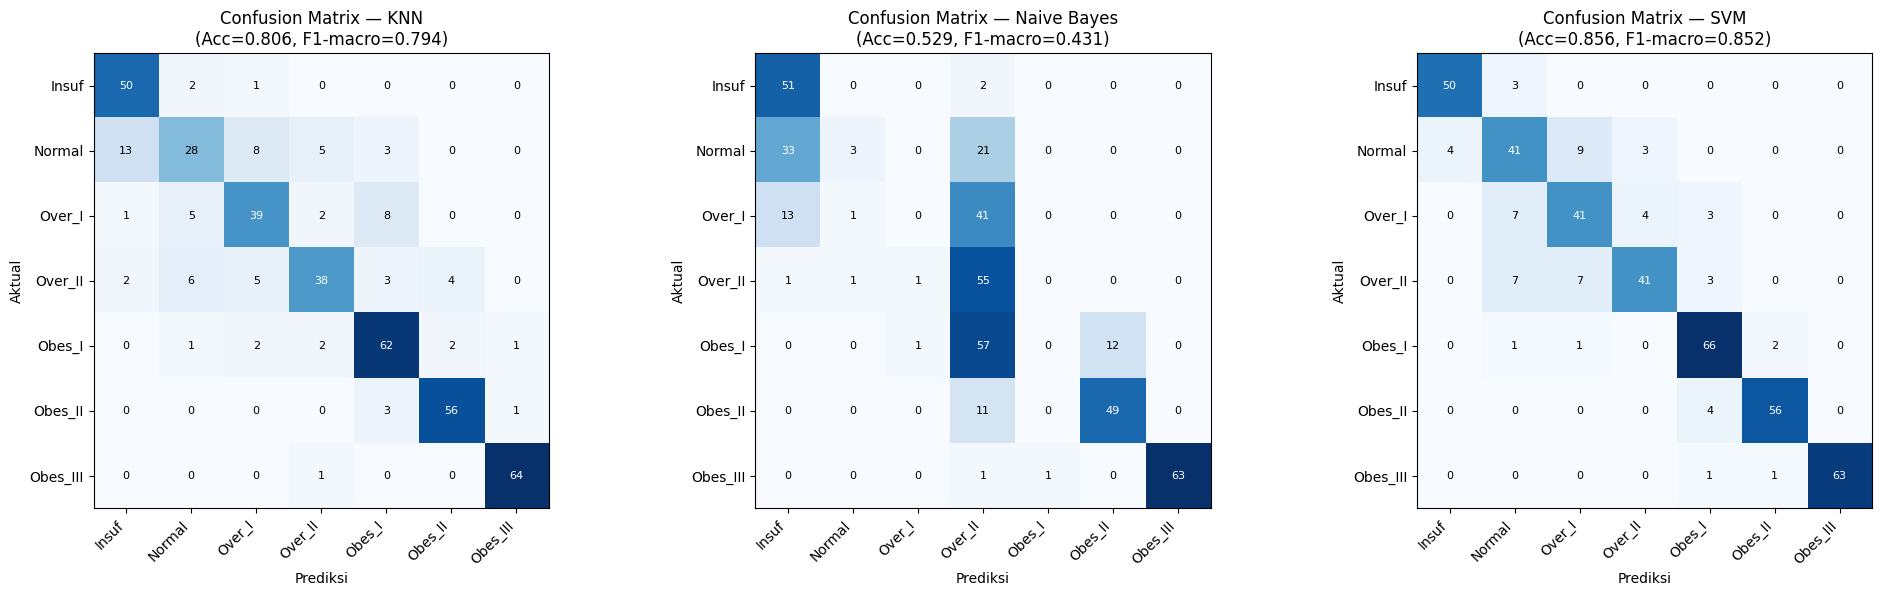

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
short_labels = ["Insuf", "Normal", "Over_I", "Over_II", "Obes_I", "Obes_II", "Obes_III"]

for ax, (name, res) in zip(axes, [("KNN", res_knn), ("Naive Bayes", res_nb), ("SVM", res_svm)]):
    cm = confusion_matrix(y_test, res["y_pred"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(7)); ax.set_xticklabels(short_labels, rotation=45, ha="right")
    ax.set_yticks(range(7)); ax.set_yticklabels(short_labels)
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
    ax.set_title(f"Confusion Matrix — {name}\n(Acc={res['accuracy']:.3f}, F1-macro={res['f1_macro']:.3f})")
    for i in range(7):
        for j in range(7):
            val = cm[i, j]
            color = "white" if val > cm.max()/2 else "black"
            ax.text(j, i, str(val), ha="center", va="center", color=color, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "soal03_confusion_matrices.png"), dpi=120)
plt.show()


## 5. Classification Report Tiap Model

In [8]:
for name, res in [("KNN", res_knn), ("Naive Bayes", res_nb), ("SVM", res_svm)]:
    print("="*70)
    print(f"CLASSIFICATION REPORT — {name}")
    print("="*70)
    print(classification_report(y_test, res["y_pred"], target_names=ORDER_TARGET, zero_division=0))


CLASSIFICATION REPORT — KNN
                     precision    recall  f1-score   support

Insufficient_Weight       0.76      0.94      0.84        53
      Normal_Weight       0.67      0.49      0.57        57
 Overweight_Level_I       0.71      0.71      0.71        55
Overweight_Level_II       0.79      0.66      0.72        58
     Obesity_Type_I       0.78      0.89      0.83        70
    Obesity_Type_II       0.90      0.93      0.92        60
   Obesity_Type_III       0.97      0.98      0.98        65

           accuracy                           0.81       418
          macro avg       0.80      0.80      0.79       418
       weighted avg       0.80      0.81      0.80       418

CLASSIFICATION REPORT — Naive Bayes
                     precision    recall  f1-score   support

Insufficient_Weight       0.52      0.96      0.68        53
      Normal_Weight       0.60      0.05      0.10        57
 Overweight_Level_I       0.00      0.00      0.00        55
Overweight_Level_

In [9]:
import json
class_reports = {}
for name, res in [("KNN", res_knn), ("Naive Bayes", res_nb), ("SVM", res_svm)]:
    rep = classification_report(y_test, res["y_pred"], target_names=ORDER_TARGET,
                                  zero_division=0, output_dict=True)
    class_reports[name] = rep

with open(os.path.join(REPORTS_DIR, "classification_reports.json"), "w") as f:
    json.dump(class_reports, f, indent=2, default=str)
print("Classification reports (JSON) disimpan ke: reports/classification_reports.json")


Classification reports (JSON) disimpan ke: reports/classification_reports.json


## 6. Diskusi Karakteristik Model

**a. Sensitivitas terhadap scaling (KNN & SVM)**
KNN dan SVM (kernel RBF) sangat sensitif terhadap skala fitur karena keduanya berbasis jarak/dot
product antar titik data. Tanpa `StandardScaler`, fitur dengan rentang besar (mis. `Weight` 39-173 kg)
akan mendominasi perhitungan jarak dibanding fitur skala kecil (mis. `FCVC` 1-3), sehingga
performa kedua model bisa anjlok drastis. Pada pipeline ini, scaling sudah diterapkan (fit hanya
di `X_train`), sehingga kontribusi tiap fitur terhadap jarak/margin menjadi setara.

**b. Asumsi independensi Naive Bayes**
`GaussianNB` mengasumsikan (i) fitur berdistribusi normal dan (ii) fitur saling independen
secara kondisional terhadap kelas. Pada dataset ini, asumsi independensi **dilanggar** secara
nyata — misalnya `Weight` dan `Height` jelas berkorelasi (BMI), demikian pula `FAVC` dengan
`NCP`/`CAEC`. Pelanggaran asumsi ini biasanya membuat Naive Bayes kalah akurat dibanding KNN/SVM,
namun tetap berguna sebagai baseline cepat dan sangat ringan secara komputasi.

**c. Kompleksitas komputasi**
- **KNN**: training nyaris instan (hanya menyimpan data), namun inference *lambat* (O(n) per
  prediksi tanpa struktur indeks tambahan) — terlihat dari `train_ms` yang sangat kecil tapi
  beban sesungguhnya ada di tahap prediksi.
- **Naive Bayes**: training & inference tercepat secara keseluruhan, kompleksitas linear
  terhadap jumlah fitur dan sampel — cocok sebagai *quick baseline*.
- **SVM (RBF)**: training paling berat di antara ketiganya, kompleksitas mendekati O(n²)-O(n³)
  tergantung jumlah support vector; terlihat dari `train_ms` & jumlah `support vectors per kelas`
  yang dicetak di atas.

**d. Interpretabilitas**
- **Naive Bayes** paling mudah diinterpretasi: bisa langsung membaca *prior* dan rata-rata/varians
  per fitur per kelas.
- **KNN** cukup mudah dijelaskan secara intuitif ("mirip dengan k tetangga terdekat"), namun tidak
  menghasilkan bobot fitur eksplisit.
- **SVM (RBF)** paling sulit diinterpretasi karena keputusan dibentuk dalam ruang fitur
  ber-dimensi tinggi (kernel trick), bukan ruang fitur asli — koefisien tidak langsung
  bermakna seperti pada model linear.

**e. Catatan keterkaitan dengan temuan Soal 02**
Sebagaimana didokumentasikan di Soal 02, fitur `Height` & `Weight` memiliki hubungan
near-deterministik dengan target (via BMI). Ketiga model baseline di atas dilatih dengan
menyertakan fitur ini (skenario *full features*), sehingga performa tinggi yang dicapai
sebagian mencerminkan kemampuan model "menangkap" rumus BMI, bukan murni pola perilaku.
Hal ini akan dieksplorasi lebih lanjut pada tahap optimasi (Soal 04).


## 7. Ringkasan Soal 03

1. Tiga model wajib (KNN, Naive Bayes, SVM) berhasil dilatih dengan pipeline & split data yang
   identik dengan Soal 02 (`random_state=42`, stratified 80:20).
2. Evaluasi memakai accuracy, precision/recall/F1 (weighted), F1-macro, balanced accuracy, dan
   confusion matrix per kelas — bukan hanya accuracy, sesuai arahan rubrik (metrik macro-F1 penting
   karena ada 7 kelas).
3. Artefak yang dihasilkan:
   - `reports/soal03_baseline_metrics.csv`
   - `reports/soal03_confusion_matrices.png`
   - `reports/classification_reports.json`
   - `models/knn.joblib`, `models/naive_bayes.joblib`, `models/svm.joblib` (diperbarui ulang)
4. Hasil baseline ini menjadi acuan pembanding pada Soal 04 (optimasi hyperparameter, CV, feature
   selection, dan error analysis).
